# Pytorch Playground

Deep learning framework aid in development and deployment of neural networks. Some of the popular frameworks are JAX, pytorch, and others. Matplotlib and numpy are other framework for visualization and numerical computation.

In [70]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Subset
from torchvision import datasets, transforms

## Tensors
However, in all the frameworks a data structure called **tensors** is used. The tensors are allocated and initialized using different functions.


In [69]:
x1 = torch.tensor([[2, 1]]) #2-d tensor
x2 = torch.tensor([[1],[2]])
C = torch.mm(x1,x2)
print(C)

tensor([[4]])


Some of the functions are in sub-libraries. e.g. torch.nn.functional.

In [71]:
import torch.nn.functional as F
x2 = torch.tensor([2, 1, -0.5])
relu_out = F.relu(x2)
print(f"ReLU: {relu_out}")

ReLU: tensor([2., 1., 0.])


**Task 1**: Use one of the functions and visualize it with matplotlib.
* zeros()
* ones()
* randn()
* eye()
* others

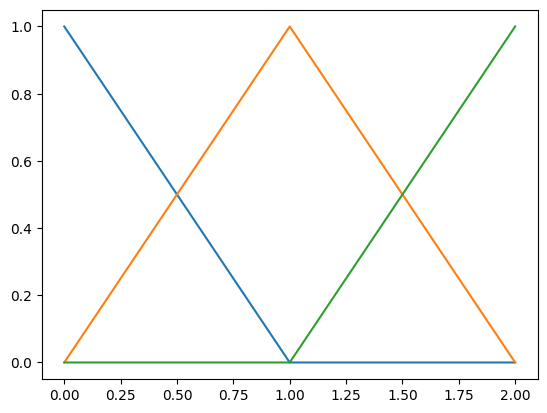

In [42]:
#TODO
import numpy as np
import matplotlib as mp

# v = np.zeros(2)
# v = np.random.randn(4)
v = np.eye(3)
plt.plot(v)

plt.show()

## Data and Dataset

Training machine learning needs large datasets. These can be images, audio, words, and others represented as tensors. **MNIST** is a data containing grayscale images of handwritten digits (0-9) with resolution of 28x28 pixels. It not only contains images but als ground truth labels.  The dataset has 60,000 training images and 10,000 test images

 The original paper in 1989 used only 7291 training images and 2007 test images of 16x16 pixels.  The images in MNIST Dataset are resized from 28x28 to 16x16. Furthermore, the pixels are scaled from (0,255) to (0,1)

In [72]:

transform = transforms.Compose([
    transforms.Resize((16, 16)),
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root='./data', train=True, download=False, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=False, transform=transform)
train_subset_size = 7291
test_subset_size = 2007
train_subset = torch.utils.data.Subset(train_dataset, range(train_subset_size))
test_subset = torch.utils.data.Subset(test_dataset, range(test_subset_size))

Shape is a important concept in deep learning, as it indicates the organization of data, MNIST images in PyTorch are always stored as $C \times H \times W$ (Channels, Height, Width). The image pixel in MNIST is grayscale therefore, the number of channels is 1.



**Task 2** Find out the shape in an MNIST image. Visualize a sample image with its label using matplotlib.

torch.Size([60000, 28, 28])
torch.Size([10000, 28, 28])
<class 'tuple'>
2
torch.Size([1, 16, 16])


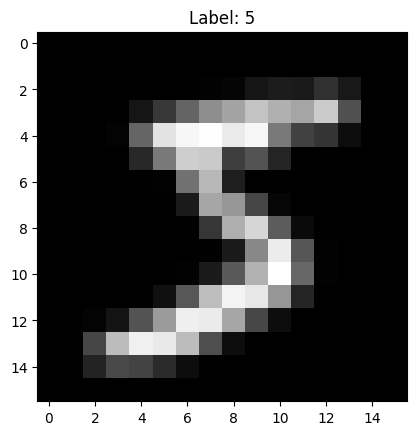

In [74]:
#TODO
print(train_dataset.data.shape)
print(test_dataset.data.shape)

print(type(train_dataset[0]))
print(len(train_dataset[0]))

image, label = train_dataset[0]
print(image.shape)

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")

plt.show()


## Data preprocesing

Data preprocessing plays a major role in Machine Learning training.

['X', 'Y']
['X', 'Y']
(7291, 1, 16, 16)
(7291, 10)
(2007, 1, 16, 16)
(2007, 10)
--- X ---
  Shape:    (7291, 1, 16, 16)
  Dtype:    float32
  Min:      -1.0
  Max:      1.0
  Mean:     -0.7368
  Std:      0.5280

--- Y ---
  Shape:    (7291, 10)
  Dtype:    float32
  Min:      -1.0
  Max:      1.0
  Mean:     -0.8000
  Std:      0.6000

  Class -1.0: 1245097 samples
  Class -0.9921568632125854: 26813 samples
  Class -0.9843137264251709: 16475 samples
  Class -0.9764705896377563: 12940 samples
  Class -0.9686274528503418: 10987 samples
  Class -0.9607843160629272: 9693 samples
  Class -0.9529411792755127: 8682 samples
  Class -0.9450980424880981: 7723 samples
  Class -0.9372549057006836: 7039 samples
  Class -0.929411768913269: 6513 samples
  Class -0.9215686321258545: 5867 samples
  Class -0.9137254953384399: 5562 samples
  Class -0.9058823585510254: 4950 samples
  Class -0.8980392217636108: 4885 samples
  Class -0.8901960849761963: 4549 samples
  Class -0.8823529481887817: 4550 sample

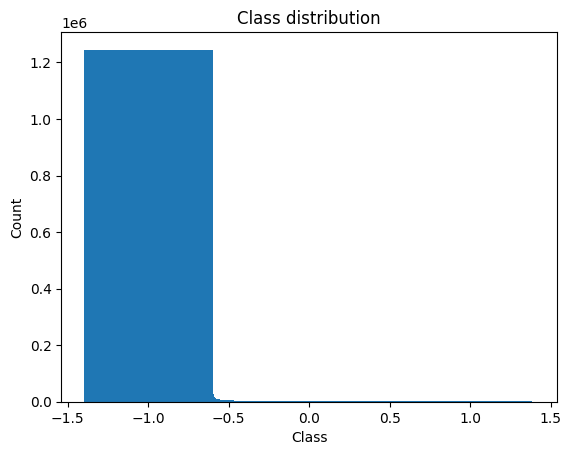

In [82]:
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=len(train_subset), shuffle=True)
test_loader = torch.utils.data.DataLoader(test_subset, batch_size=len(test_subset), shuffle=True)
x_train, y_train = next(iter(train_loader))
x_test, y_test = next(iter(test_loader))
dataset_dict = {
    'train': (x_train, y_train, 7291),
    'test': (x_test, y_test, 2007)
}

for split_name, (x_raw, y_raw, n) in dataset_dict.items():
    x_processed = (x_raw[:n] * 2.0) - 1.0
    y_processed = F.one_hot(y_raw[:n], num_classes=10).float()
    y_processed = (y_processed * 2.0) - 1.0
    x_final = x_processed.numpy().astype(np.float32)
    y_final = y_processed.numpy().astype(np.float32)
    filename = f"./data/{split_name}1989.npz"
    np.savez(filename, X=x_final, Y=y_final)

data_train = np.load('./data/train1989.npz')
print(data_train.files)

data_test = np.load('./data/test1989.npz')
print(data_test.files)

x = data_train['X']
y = data_train['Y']
print(x.shape)
print(y.shape)

x = data_test['X']
y = data_test['Y']
print(x.shape)
print(y.shape)

for key in data_train.files:
    arr = data_train[key]
    print(f"--- {key} ---")
    print(f"  Shape:    {arr.shape}")
    print(f"  Dtype:    {arr.dtype}")
    print(f"  Min:      {arr.min()}")
    print(f"  Max:      {arr.max()}")
    print(f"  Mean:     {arr.mean():.4f}")
    print(f"  Std:      {arr.std():.4f}")
    print()

    labels = data_train['X'] 

unique, counts = np.unique(labels, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls}: {cnt} samples")

plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class distribution")
plt.show()

**Task 3**: However, the initial paper had different number of training and test images and dimensions. The notebook in above code cell is preprocessing the dataset and writes the preprocessed data in a file. Write in following markdown cell the characteristics of the dataset and in what format is the file? what is npz format?

#TODO


1. Characteristics of the dataset: 

- Size: 4 Attributes (data, targets, classes, class_to_idx) and the actual train test set had 60000 observations, the subset 7291. The test set had 10000 observations and the subset 2007.

In [83]:
print(len(train_dataset))

print("Images shape:", train_dataset.data.shape)
print("Labels shape:", train_dataset.targets.shape)
print("Classes:", train_dataset.classes)
print("Class to index:", train_dataset.class_to_idx)


60000
Images shape: torch.Size([60000, 28, 28])
Labels shape: torch.Size([60000])
Classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
Class to index: {'0 - zero': 0, '1 - one': 1, '2 - two': 2, '3 - three': 3, '4 - four': 4, '5 - five': 5, '6 - six': 6, '7 - seven': 7, '8 - eight': 8, '9 - nine': 9}


Data Types: Tensor, list, dictionary (see below)

In [84]:
print(type(train_dataset.data))         # torch.Tensor
print(train_dataset.data.dtype)         # torch.uint8

print(type(train_dataset.targets))      # torch.Tensor
print(train_dataset.targets.dtype)      # torch.int64 (long)

print(type(train_dataset.classes))      # list
print(type(train_dataset.class_to_idx)) # dict


<class 'torch.Tensor'>
torch.uint8
<class 'torch.Tensor'>
torch.int64
<class 'list'>
<class 'dict'>



- Quality: The size is being reduced from 28*28 to 16*16 which is a lossy resize (see below)

In [92]:
transform = transforms.Compose([
    transforms.Resize((16, 16)),  # quality reduction here
    transforms.ToTensor()         # converts to float, scales to [0,1]
])



- Distribution: 
a) The frequency of the pixel values is heavily skewed to the right because most pixels in a handwritten digit image are background. Only the stroke pixels have high values.
Variance is very high before normalization.
b) The number of digits is slightly right-skewed


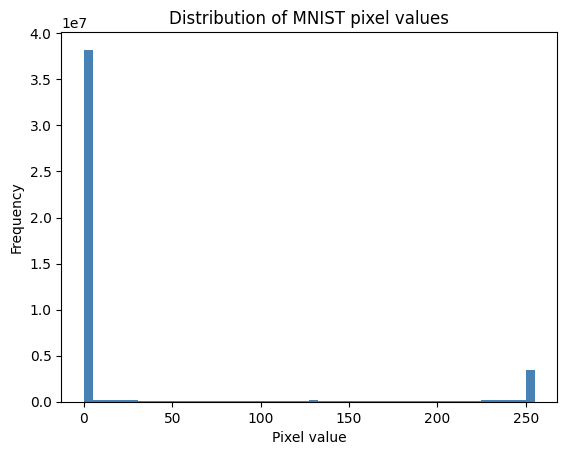

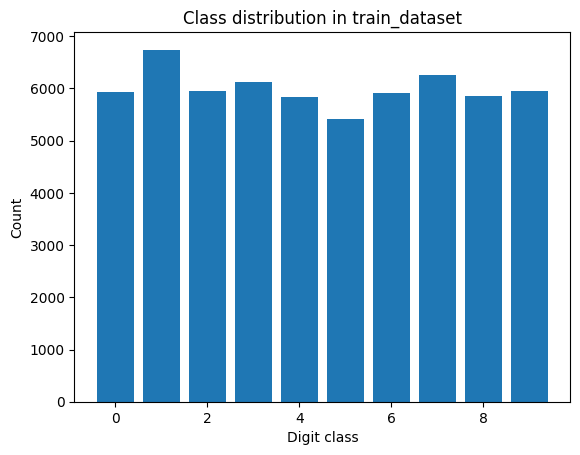

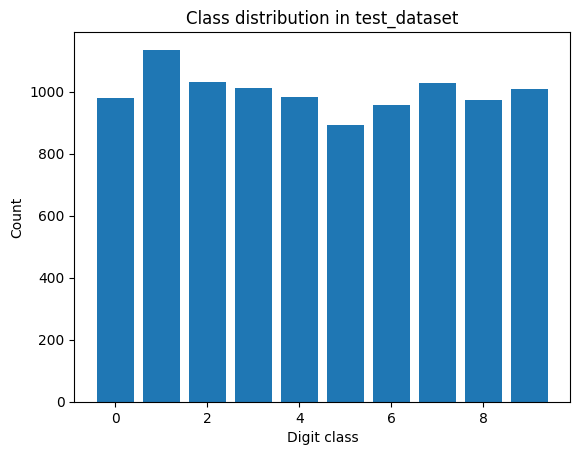

Range:
  Min: 0.0
  Max: 255.0
  Range: 255.0

Variance & Std:
  Variance: 6172.8505859375
  Std Dev: 78.56748962402344


In [91]:
pixels = train_dataset.data.float().numpy().flatten()

plt.hist(pixels, bins=50, color='steelblue')
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.title("Distribution of MNIST pixel values")
plt.show()

unique, counts = torch.unique(train_dataset.targets, return_counts=True)

plt.bar(unique.numpy(), counts.numpy())
plt.xlabel("Digit class")
plt.ylabel("Count")
plt.title("Class distribution in train_dataset")
plt.show()

unique, counts = torch.unique(test_dataset.targets, return_counts=True)

plt.bar(unique.numpy(), counts.numpy())
plt.xlabel("Digit class")
plt.ylabel("Count")
plt.title("Class distribution in test_dataset")
plt.show()

pixels = train_dataset.data.float()

print("Range:")
print("  Min:", pixels.min().item())
print("  Max:", pixels.max().item())
print("  Range:", (pixels.max() - pixels.min()).item())

print("\nVariance & Std:")
print("  Variance:", pixels.var().item())
print("  Std Dev:", pixels.std().item())



- Relationships between features

/Users/miriam/Documents/GitHub/thn-aia-classroom-create-lenet1-cnn-in-pytorch-aia-lenet-template/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/miriam/Documents/GitHub/thn-aia-classroom-create-lenet1-cnn-in-pytorch-aia-lenet-template/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


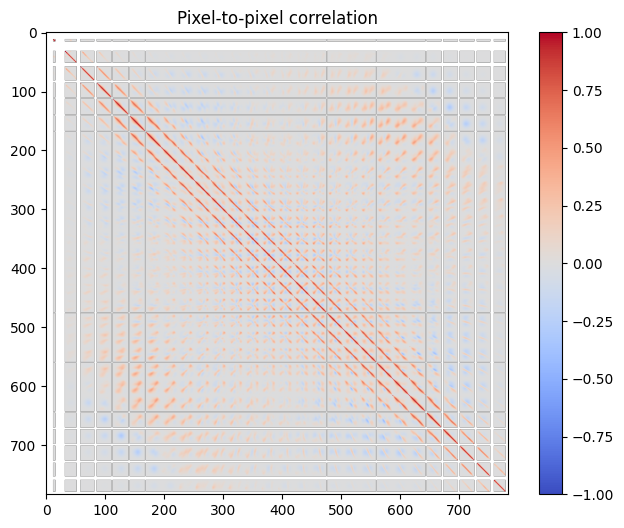

In [ ]:
# Flatten each image to 256 pixels, use a sample for speed
pixels = train_dataset.data.float().numpy()  # (60000, 28, 28)
pixels_flat = pixels.reshape(60000, -1)      # (60000, 784)

corr = np.corrcoef(pixels_flat, rowvar=False)  # (784, 784)

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.title("Pixel-to-pixel correlation")
plt.show()



- Provenance & Context

2. The format npz is Numpys format for saving multiple arrays in a single compressed file